## Análisis y Tratamiento Digital de Imágenes Satelitales: TP4

In [ ]:
pip install rasterio matplotlib
pip install opencv-python

In [1]:
from __future__ import annotations
import os
import numpy as np
from PIL import Image
import matplotlib
import matplotlib.pyplot as plt
import requests
import io
from PIL import Image
from io import BytesIO
from IPython.display import display
import cv2

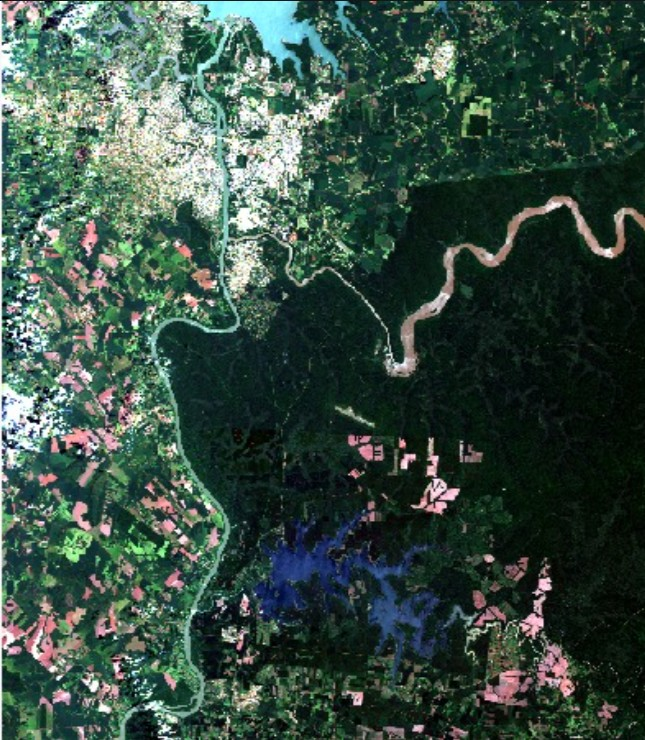

In [2]:
url = "https://raw.githubusercontent.com/epineda504/Analisis_Tratamiento_Imagenes_Satelitales_TP4/refs/heads/main/LC08_224-078-2018-01-05_Original.jpeg"

response = requests.get(url)

img = Image.open(BytesIO(response.content))

display(img)

### 1. Implementar la transformada de Hough para detectar rectas y aplicarla a la imagen Test.

Tamaño original: (740, 645, 3)
Tamaño de trabajo: (740, 645, 3)
Píxeles de borde: 40128
rho =     2.0 px   theta =    0.0°   votos = 325
rho =    -3.0 px   theta =  -90.0°   votos = 204
rho =   342.0 px   theta =   45.0°   votos = 197
rho =   400.0 px   theta =   45.0°   votos = 180
rho =   383.0 px   theta =   45.0°   votos = 172
rho =   157.0 px   theta =    4.0°   votos = 164


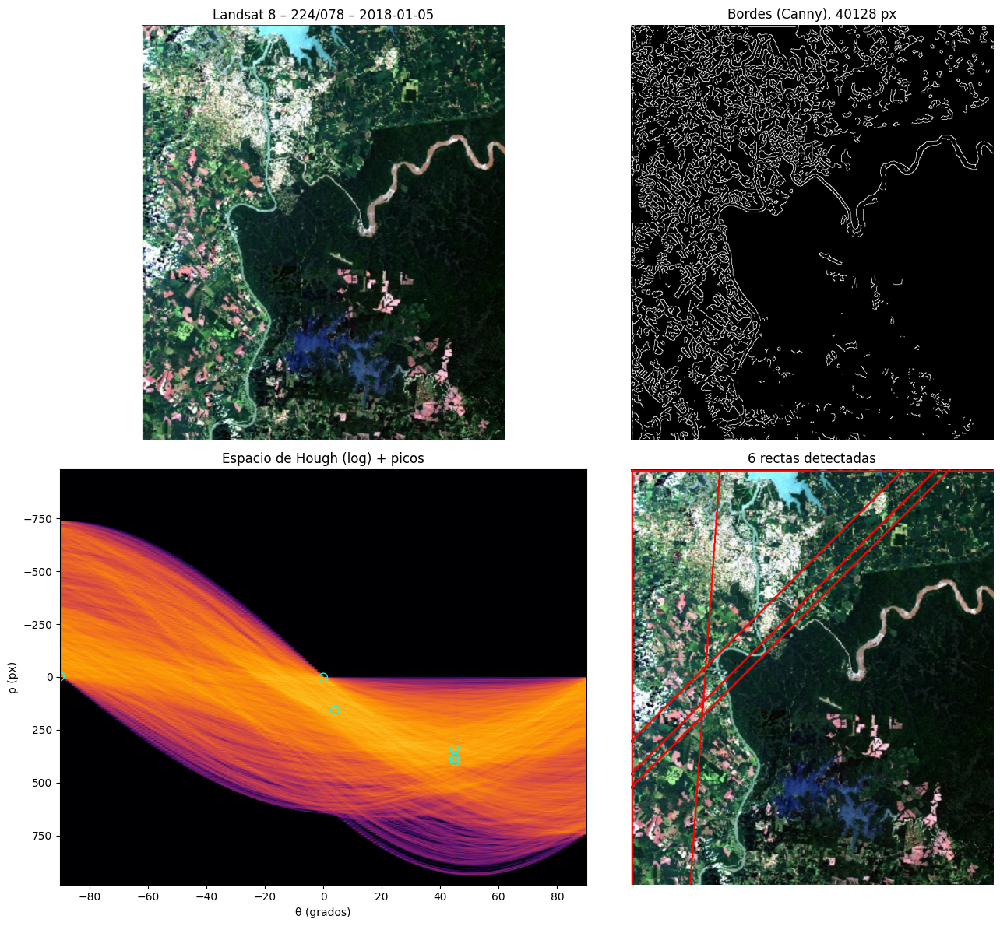

OpenCV: 12 rectas


In [5]:
# %% Funciones
def load_image_url(url: str) -> np.ndarray:
    """Descarga una imagen y la devuelve como array RGB uint8."""
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return np.asarray(Image.open(BytesIO(r.content)).convert("RGB"))


def hough_lines_acc(edges: np.ndarray, theta_res: float = 1.0, rho_res: float = 1.0):
    """Acumulador de Hough con parametrización rho = x*cos(theta) + y*sin(theta).
    edges: imagen binaria (bordes != 0). theta_res en grados, rho_res en píxeles.
    Devuelve (acumulador, rhos, thetas[rad])."""
    h, w = edges.shape
    diag = int(np.ceil(np.hypot(h, w)))
    thetas = np.deg2rad(np.arange(-90, 90, theta_res))
    rhos = np.arange(-diag, diag + rho_res, rho_res)
    acc = np.zeros((len(rhos), len(thetas)), dtype=np.int32)

    ys, xs = np.nonzero(edges)
    for j, (c, s) in enumerate(zip(np.cos(thetas), np.sin(thetas))):
        r_idx = np.round((xs * c + ys * s + diag) / rho_res).astype(np.int64)
        acc[:, j] = np.bincount(r_idx, minlength=len(rhos))[: len(rhos)]
    return acc, rhos, thetas


def hough_peaks(acc: np.ndarray, n_peaks: int = 20, threshold: float = 0.5,
                nhood: tuple[int, int] = (21, 11)):
    """Picos del acumulador con supresión de no-máximos iterativa.
    threshold: fracción del máximo. nhood: (filas rho, columnas theta), impares.
    Devuelve lista de (i_rho, j_theta, votos)."""
    acc_c = acc.copy()
    thr = threshold * acc.max()
    dr, dt = nhood[0] // 2, nhood[1] // 2
    peaks = []
    for _ in range(n_peaks):
        i, j = np.unravel_index(np.argmax(acc_c), acc_c.shape)
        if acc_c[i, j] < thr:
            break
        peaks.append((i, j, int(acc_c[i, j])))
        acc_c[max(0, i - dr): i + dr + 1, max(0, j - dt): j + dt + 1] = 0
    return peaks


def draw_lines(img: np.ndarray, peaks, rhos, thetas,
               color=(255, 0, 0), thickness: int = 2) -> np.ndarray:
    """Dibuja las rectas (rho, theta) de cada pico sobre una copia de img."""
    out = img.copy()
    L = int(np.hypot(*img.shape[:2]))
    for i, j, _ in peaks:
        rho, th = rhos[i], thetas[j]
        c, s = np.cos(th), np.sin(th)
        x0, y0 = rho * c, rho * s  # punto de la recta más cercano al origen
        p1 = (int(x0 - L * s), int(y0 + L * c))
        p2 = (int(x0 + L * s), int(y0 - L * c))
        cv2.line(out, p1, p2, color, thickness)
    return out


# %% Carga de la imagen
url = ("https://raw.githubusercontent.com/epineda504/"
       "Analisis_Tratamiento_Imagenes_Satelitales_TP4/refs/heads/main/"
       "LC08_224-078-2018-01-05_Original.jpeg")
img_sat = load_image_url(url)
print("Tamaño original:", img_sat.shape)

# Reducir tamaño para quedarse con estructuras lineales grandes
max_side = 1200
scale = min(1.0, max_side / max(img_sat.shape[:2]))
if scale < 1:
    img_sat = cv2.resize(img_sat, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
print("Tamaño de trabajo:", img_sat.shape)

# %% Preprocesado: máscara de no-data + bordes
gray = cv2.cvtColor(img_sat, cv2.COLOR_RGB2GRAY)

# Excluir el marco negro de la escena (sus lados dominarían el acumulador)
valid = (gray > 10).astype(np.uint8)
valid = cv2.erode(valid, np.ones((15, 15), np.uint8))

blur = cv2.GaussianBlur(gray, (7, 7), 2)
med = np.median(blur[valid > 0]) if valid.any() else np.median(blur)
edges = cv2.Canny(blur, int(max(0, 0.66 * med)), int(min(255, 1.33 * med)))
edges[valid == 0] = 0
print("Píxeles de borde:", np.count_nonzero(edges))

# %% Transformada de Hough
acc, rhos, thetas = hough_lines_acc(edges, theta_res=1.0, rho_res=1.0)
peaks = hough_peaks(acc, n_peaks=15, threshold=0.5, nhood=(31, 15))
result = draw_lines(img_sat, peaks, rhos, thetas)

for i, j, v in peaks:
    print(f"rho = {rhos[i]:7.1f} px   theta = {np.rad2deg(thetas[j]):6.1f}°   votos = {v}")

# %% Visualización
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
ax[0, 0].imshow(img_sat)
ax[0, 0].set_title("Landsat 8 – 224/078 – 2018-01-05")
ax[0, 1].imshow(edges, cmap="gray")
ax[0, 1].set_title(f"Bordes (Canny), {np.count_nonzero(edges)} px")

ax[1, 0].imshow(np.log1p(acc), cmap="inferno", aspect="auto",
                extent=[-90, 90, rhos[-1], rhos[0]])
ax[1, 0].scatter([np.rad2deg(thetas[j]) for _, j, _ in peaks],
                 [rhos[i] for i, _, _ in peaks],
                 s=60, facecolors="none", edgecolors="cyan")
ax[1, 0].set_xlabel("θ (grados)")
ax[1, 0].set_ylabel("ρ (px)")
ax[1, 0].set_title("Espacio de Hough (log) + picos")

ax[1, 1].imshow(result)
ax[1, 1].set_title(f"{len(peaks)} rectas detectadas")

for a in (ax[0, 0], ax[0, 1], ax[1, 1]):
    a.axis("off")
plt.tight_layout()
plt.show()

# %% Validación contra OpenCV (opcional)
# OpenCV usa theta en [0°, 180°): una recta con theta < 0 acá aparece allá
# como theta + 180° con rho de signo opuesto. No suprime vecinos.
lines_cv = cv2.HoughLines(edges, 1, np.pi / 180, threshold=int(0.5 * acc.max()))
print("OpenCV:", 0 if lines_cv is None else len(lines_cv), "rectas")

### 2. Utilizar el metodo SIFT para reconocimiento de objetos en una imagen. La idea de este ejercicio es reconocer si dos imagenes son, en realidad, la misma. Esto puede realizarse contando los descriptores de cada una y las coincidencias entre los descriptores. Aplicar el metodo a diferentes pares de imagenes, observando el comportamiento bajo rotacion, traslacion, cambios en la iluminacion, cambios de escala y cambio de perspectiva. Utilizar imagenes satelitales opticas.

Escena de trabajo: (740, 645, 3)
Fracción válida de la escena: 94.2%
CROP = 222 px | base en (200, 250) | negativo en (200, 25)


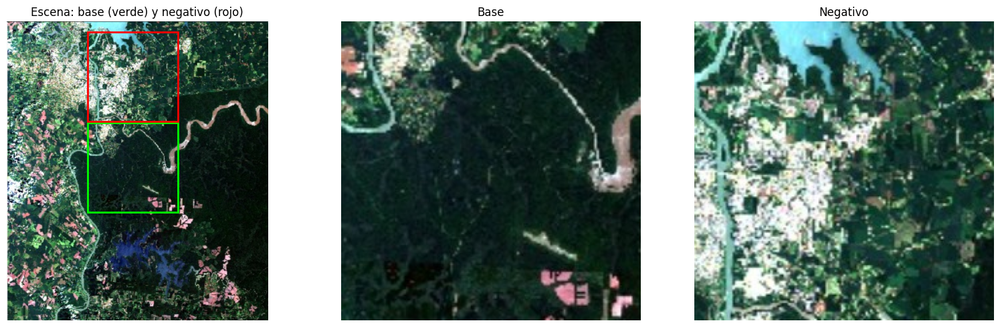

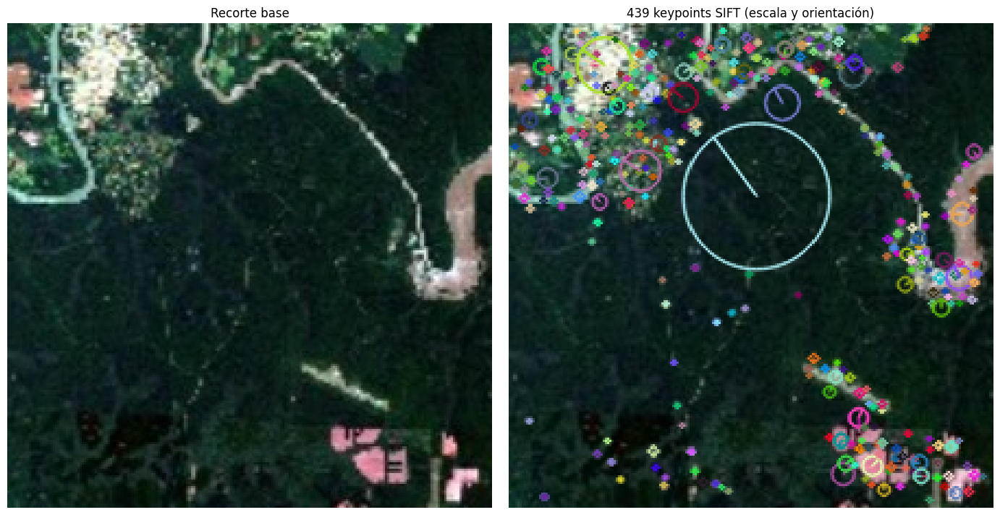

Par                                             kp1   kp2  coinc  %coinc inliers inl/coinc  err px  decisión
------------------------------------------------------------------------------------------------------------
Idéntica                                        439   439    439  100.0%     439      1.00    0.00  MISMA
Traslación (66, 44) px                          439   330    173   52.4%     171      0.99    0.06  MISMA
Rotación 30°                                    439   471    277   63.1%     273      0.99    0.15  MISMA
Rotación 90°                                    439   435    417   95.9%     416      1.00    0.51  MISMA
Escala 0.5                                      439    86     78   90.7%      67      0.86    0.20  MISMA
Escala 2.0                                      439  1065    355   80.9%     354      1.00    0.35  MISMA
Iluminación: brillo -60, contraste 0.7          439   199    117   58.8%     113      0.97    0.21  MISMA
Iluminación: gamma 2.2                  

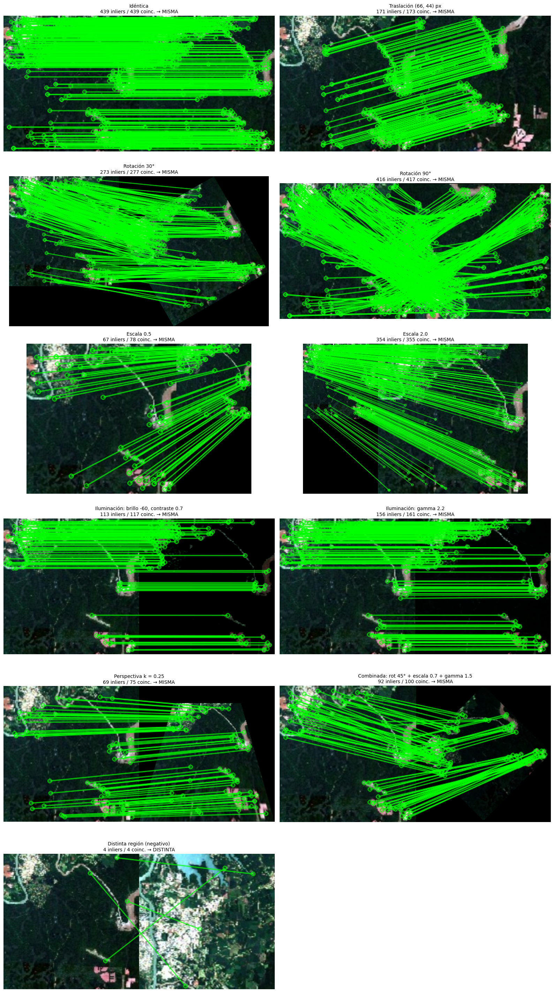

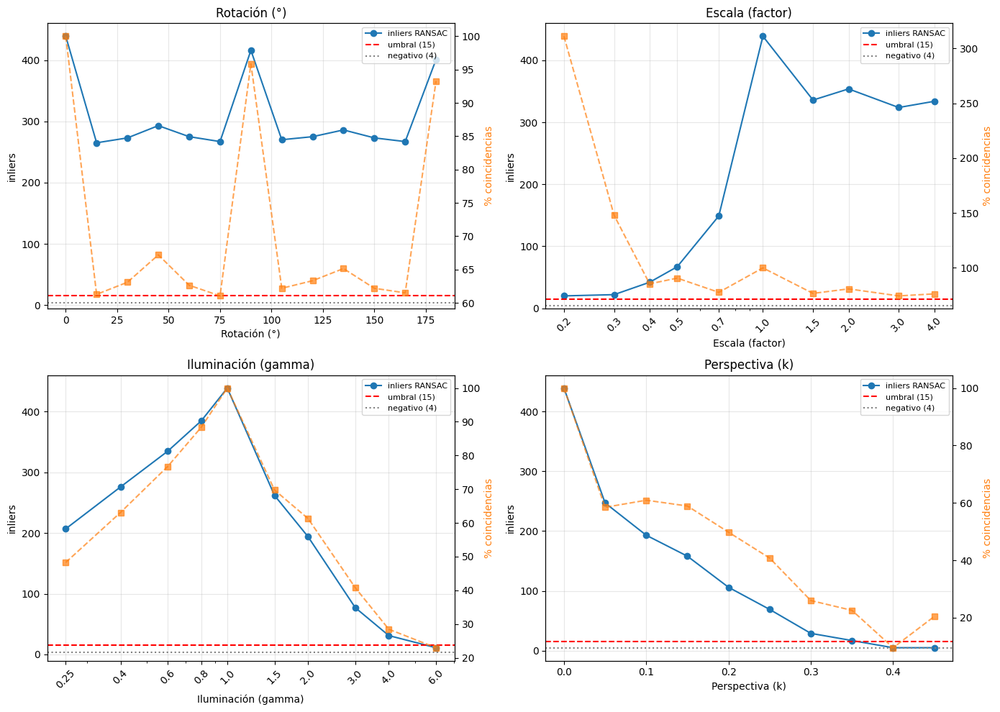

In [12]:
# %% Parámetros
URL = ("https://raw.githubusercontent.com/epineda504/"
       "Analisis_Tratamiento_Imagenes_Satelitales_TP4/refs/heads/main/"
       "LC08_224-078-2018-01-05_Original.jpeg")
MAX_SIDE = 1600      # tamaño de trabajo de la escena
CROP = 500           # lado máximo del recorte base (se reduce solo si no entra)
RATIO = 0.75         # test de razón de Lowe
RANSAC_THR = 5.0     # umbral de reproyección para RANSAC (px)
MIN_INLIERS = 15     # criterio de decisión: mínimo de inliers
MIN_INL_RATIO = 0.25 # criterio de decisión: inliers / coincidencias

SIFT = cv2.SIFT_create()


# %% Carga de la escena y máscara de píxeles válidos
def load_image_url(url: str) -> np.ndarray:
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return np.asarray(Image.open(BytesIO(r.content)).convert("RGB"))


scene = load_image_url(URL)
s = min(1.0, MAX_SIDE / max(scene.shape[:2]))
if s < 1:
    scene = cv2.resize(scene, None, fx=s, fy=s, interpolation=cv2.INTER_AREA)
H_img, W_img = scene.shape[:2]
print("Escena de trabajo:", scene.shape)

# No-data = solo los píxeles oscuros conectados al borde (el marco de la escena),
# no el agua ni las sombras dentro de la escena
gray_scene = cv2.cvtColor(scene, cv2.COLOR_RGB2GRAY)
dark = (gray_scene <= 10).astype(np.uint8)
_, labels = cv2.connectedComponents(dark, connectivity=8)
border_labels = np.unique(np.concatenate([labels[0], labels[-1], labels[:, 0], labels[:, -1]]))
border_labels = border_labels[border_labels != 0]
nodata = np.isin(labels, border_labels)
valid_scene = cv2.erode((~nodata).astype(np.uint8), np.ones((15, 15), np.uint8))
print(f"Fracción válida de la escena: {valid_scene.mean():.1%}")


# %% Selección de recortes: base (centro) y negativo (otra región, sin solapamiento)
def crop(img, x, y, size=None):
    size = CROP if size is None else size
    return img[y:y + size, x:x + size].copy()


def find_crops(size, min_valid=0.98, step=25):
    cands = [(x, y)
             for y in range(0, H_img - size + 1, step)
             for x in range(0, W_img - size + 1, step)
             if valid_scene[y:y + size, x:x + size].mean() >= min_valid]
    if not cands:
        return None
    cx, cy = W_img / 2 - size / 2, H_img / 2 - size / 2
    b = min(cands, key=lambda p: (p[0] - cx) ** 2 + (p[1] - cy) ** 2)
    # Negativo: la región sin solapamiento más cercana (paisaje parecido => test exigente)
    others = [p for p in cands if abs(p[0] - b[0]) >= size or abs(p[1] - b[1]) >= size]
    if not others:
        return None
    n = min(others, key=lambda p: (p[0] - b[0]) ** 2 + (p[1] - b[1]) ** 2)
    return b, n


CROP = min(CROP, min(H_img, W_img) // 2)
found = None
while CROP >= 150:
    found = find_crops(CROP)
    if found:
        break
    CROP -= 50
assert found, "No se encontraron dos recortes válidos ni con CROP=150: revisar la máscara"

(bx, by), (nx, ny) = found
base = crop(scene, bx, by)
negative = crop(scene, nx, ny)
print(f"CROP = {CROP} px | base en ({bx}, {by}) | negativo en ({nx}, {ny})")

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
ax[0].imshow(scene)
ax[0].add_patch(plt.Rectangle((bx, by), CROP, CROP, fill=False, ec="lime", lw=2))
ax[0].add_patch(plt.Rectangle((nx, ny), CROP, CROP, fill=False, ec="red", lw=2))
ax[0].set_title("Escena: base (verde) y negativo (rojo)")
ax[1].imshow(base); ax[1].set_title("Base")
ax[2].imshow(negative); ax[2].set_title("Negativo")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()


# %% Transformaciones sintéticas (cada una devuelve imagen, H_real, máscara válida)
def full_mask(img):
    return np.full(img.shape[:2], 255, np.uint8)


def warp(img, H, size):
    """warpPerspective + máscara de la zona con contenido (sin el relleno negro)."""
    out = cv2.warpPerspective(img, H, size, flags=cv2.INTER_LINEAR, borderValue=0)
    m = cv2.warpPerspective(full_mask(img), H, size, flags=cv2.INTER_NEAREST)
    return out, cv2.erode(m, np.ones((5, 5), np.uint8))


def t_rotation(img, angle, scale=1.0):
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    c, s_ = abs(M[0, 0]), abs(M[0, 1])
    nw, nh = int(h * s_ + w * c), int(h * c + w * s_)
    M[0, 2] += nw / 2 - w / 2
    M[1, 2] += nh / 2 - h / 2
    H = np.vstack([M, [0, 0, 1]])
    out, m = warp(img, H, (nw, nh))
    return out, H, m


def t_scale(img, f):
    interp = cv2.INTER_AREA if f < 1 else cv2.INTER_CUBIC
    out = cv2.resize(img, None, fx=f, fy=f, interpolation=interp)
    return out, np.diag([f, f, 1.0]), full_mask(out)


def t_perspective(img, k):
    """Inclinación tipo 'keystone': el borde superior se acorta un k*w por lado."""
    h, w = img.shape[:2]
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    dst = np.float32([[k * w, k * h / 2], [w - k * w, k * h / 2], [w, h], [0, h]])
    H = cv2.getPerspectiveTransform(src, dst)
    out, m = warp(img, H, (w, h))
    return out, H, m


def t_illumination(img, gain=1.0, bias=0.0, gamma=1.0):
    x = (img.astype(np.float32) / 255.0) ** gamma
    out = np.clip(x * 255.0 * gain + bias, 0, 255).astype(np.uint8)
    return out, np.eye(3), full_mask(out)


def t_translation(tx, ty):
    """Recorte desplazado dentro de la escena: entra contenido nuevo y sale parte del viejo.
    Si el desplazamiento se sale de la escena, se invierte su sentido."""
    if not 0 <= bx + tx <= W_img - CROP:
        tx = -tx
    if not 0 <= by + ty <= H_img - CROP:
        ty = -ty
    x, y = bx + tx, by + ty
    x = int(np.clip(x, 0, W_img - CROP))
    y = int(np.clip(y, 0, H_img - CROP))
    tx, ty = x - bx, y - by
    out = crop(scene, x, y)
    H = np.array([[1, 0, -tx], [0, 1, -ty], [0, 0, 1]], dtype=float)
    return out, H, (crop(valid_scene, x, y) * 255).astype(np.uint8), (tx, ty)


# %% SIFT + matching + verificación geométrica
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) if img.ndim == 3 else img


def as_mask(mask, img):
    """Normaliza la máscara al formato que exige OpenCV: uint8 de 1 canal (0/255),
    contigua en memoria y del mismo alto/ancho que la imagen."""
    if mask is None:
        return None
    m = np.asarray(mask)
    if m.ndim == 3:
        m = m[..., 0]
    m = np.where(m > 0, 255, 0).astype(np.uint8)
    h, w = img.shape[:2]
    if m.shape != (h, w):
        m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)
    return np.ascontiguousarray(m)


def sift_match(img1, img2, mask1=None, mask2=None):
    g1 = np.ascontiguousarray(to_gray(img1))
    g2 = np.ascontiguousarray(to_gray(img2))
    kp1, d1 = SIFT.detectAndCompute(g1, as_mask(mask1, g1))
    kp2, d2 = SIFT.detectAndCompute(g2, as_mask(mask2, g2))
    res = dict(kp1=kp1, kp2=kp2, good=[], inliers=[], H=None)
    if d1 is None or d2 is None or len(kp1) < 2 or len(kp2) < 2:
        return res

    knn = cv2.BFMatcher(cv2.NORM_L2).knnMatch(d1, d2, k=2)
    good = [m for m, n in (p for p in knn if len(p) == 2) if m.distance < RATIO * n.distance]
    res["good"] = good

    if len(good) >= 4:
        src = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, inl = cv2.findHomography(src, dst, cv2.RANSAC, RANSAC_THR)
        if H is not None:
            res["H"] = H
            res["inliers"] = [m for m, k in zip(good, inl.ravel()) if k]
    return res


def corner_error(H_est, H_true, shape):
    """Error medio (px) al proyectar las esquinas de la imagen base con H estimada vs real."""
    if H_est is None or H_true is None:
        return np.nan
    h, w = shape[:2]
    c = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    p_est = cv2.perspectiveTransform(c, H_est)
    p_true = cv2.perspectiveTransform(c, H_true)
    return float(np.linalg.norm(p_est - p_true, axis=2).mean())


def summarize(res, H_true=None, shape=None):
    n1, n2 = len(res["kp1"]), len(res["kp2"])
    ng, ni = len(res["good"]), len(res["inliers"])
    pct = 100 * ng / max(1, min(n1, n2))
    inl_ratio = ni / ng if ng else 0.0
    same = ni >= MIN_INLIERS and inl_ratio >= MIN_INL_RATIO
    err = corner_error(res["H"], H_true, shape) if same else np.nan
    return dict(n_kp1=n1, n_kp2=n2, n_good=ng, pct_good=pct,
                n_inl=ni, inl_ratio=inl_ratio, same=same, err=err)


# %% Keypoints de la imagen base
kp_base = SIFT.detect(to_gray(base), None)
vis = cv2.drawKeypoints(base, kp_base, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(base); ax[0].set_title("Recorte base")
ax[1].imshow(vis); ax[1].set_title(f"{len(kp_base)} keypoints SIFT (escala y orientación)")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()


# %% Pares de prueba
base_mask = full_mask(base)
pairs = []  # (nombre, img2, H_real o None si son imágenes distintas, mask2)
            # mismo orden que devuelven las funciones t_*: (imagen, H, máscara)

pairs.append(("Idéntica", base, np.eye(3), base_mask))

img_t, H_t, m_t, (tx, ty) = t_translation(int(0.3 * CROP), int(0.2 * CROP))
pairs.append((f"Traslación ({tx}, {ty}) px", img_t, H_t, m_t))

pairs.append(("Rotación 30°", *t_rotation(base, 30)))
pairs.append(("Rotación 90°", *t_rotation(base, 90)))
pairs.append(("Escala 0.5", *t_scale(base, 0.5)))
pairs.append(("Escala 2.0", *t_scale(base, 2.0)))
pairs.append(("Iluminación: brillo -60, contraste 0.7", *t_illumination(base, gain=0.7, bias=-60)))
pairs.append(("Iluminación: gamma 2.2", *t_illumination(base, gamma=2.2)))
pairs.append(("Perspectiva k = 0.25", *t_perspective(base, 0.25)))

ill, _, _ = t_illumination(base, gamma=1.5, gain=0.8)
pairs.append(("Combinada: rot 45° + escala 0.7 + gamma 1.5", *t_rotation(ill, 45, 0.7)))

pairs.append(("Distinta región (negativo)", negative, None,
              (crop(valid_scene, nx, ny) * 255).astype(np.uint8)))

results = []
for name, img2, H_true, m2 in pairs:
    res = sift_match(base, img2, base_mask, m2)
    results.append((name, img2, res, summarize(res, H_true, base.shape)))


# %% Tabla de resultados
hdr = (f"{'Par':45s} {'kp1':>5s} {'kp2':>5s} {'coinc':>6s} {'%coinc':>7s} "
       f"{'inliers':>7s} {'inl/coinc':>9s} {'err px':>7s}  decisión")
print(hdr)
print("-" * len(hdr))
for name, _, _, r in results:
    print(f"{name:45s} {r['n_kp1']:5d} {r['n_kp2']:5d} {r['n_good']:6d} {r['pct_good']:6.1f}% "
          f"{r['n_inl']:7d} {r['inl_ratio']:9.2f} {r['err']:7.2f}  "
          f"{'MISMA' if r['same'] else 'DISTINTA'}")


# %% Visualización de coincidencias (solo inliers de RANSAC)
ncols = 2
nrows = int(np.ceil(len(results) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows))
for ax, (name, img2, res, r) in zip(axes.flat, results):
    shown = res["inliers"] if res["inliers"] else res["good"]
    vis = cv2.drawMatches(base, res["kp1"], img2, res["kp2"], shown, None,
                          matchColor=(0, 255, 0), singlePointColor=(255, 0, 0),
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    ax.imshow(vis)
    ax.set_title(f"{name}\n{r['n_inl']} inliers / {r['n_good']} coinc. → "
                 f"{'MISMA' if r['same'] else 'DISTINTA'}", fontsize=10)
    ax.axis("off")
for ax in axes.flat[len(results):]:
    ax.axis("off")
plt.tight_layout(); plt.show()


# %% Barrido de parámetros: comportamiento de SIFT en función de cada transformación
def sweep(values, make):
    inl, pct = [], []
    for v in values:
        img2, H, m2 = make(v)
        r = summarize(sift_match(base, img2, base_mask, m2), H, base.shape)
        inl.append(r["n_inl"])
        pct.append(r["pct_good"])
    return np.array(inl), np.array(pct)


neg_inl = next(r["n_inl"] for n, _, _, r in results if n.startswith("Distinta"))

sweeps = {
    "Rotación (°)": (np.arange(0, 181, 15), lambda a: t_rotation(base, a)),
    "Escala (factor)": (np.array([0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0, 4.0]),
                        lambda f: t_scale(base, f)),
    "Iluminación (gamma)": (np.array([0.25, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0]),
                            lambda g: t_illumination(base, gamma=g)),
    "Perspectiva (k)": (np.round(np.arange(0.0, 0.46, 0.05), 2),
                        lambda k: t_perspective(base, k)),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (label, (vals, make)) in zip(axes.flat, sweeps.items()):
    inl, pct = sweep(vals, make)
    ax.plot(vals, inl, "o-", label="inliers RANSAC")
    ax.axhline(MIN_INLIERS, color="red", ls="--", label=f"umbral ({MIN_INLIERS})")
    ax.axhline(neg_inl, color="gray", ls=":", label=f"negativo ({neg_inl})")
    ax.set_xlabel(label); ax.set_ylabel("inliers")
    if "Escala" in label or "gamma" in label:
        ax.set_xscale("log")
        ax.set_xticks(vals); ax.set_xticklabels([str(v) for v in vals], rotation=45)
    ax2 = ax.twinx()
    ax2.plot(vals, pct, "s--", color="tab:orange", alpha=0.7, label="% coincidencias")
    ax2.set_ylabel("% coincidencias", color="tab:orange")
    ax.set_title(label)
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


# %% (Opcional) Comparar dos imágenes externas cualesquiera
def compare_urls(url1: str, url2: str, max_side: int = 1000):
    imgs = []
    for u in (url1, url2):
        im = load_image_url(u)
        f = min(1.0, max_side / max(im.shape[:2]))
        imgs.append(cv2.resize(im, None, fx=f, fy=f, interpolation=cv2.INTER_AREA) if f < 1 else im)
    res = sift_match(*imgs)
    r = summarize(res)
    vis = cv2.drawMatches(imgs[0], res["kp1"], imgs[1], res["kp2"],
                          res["inliers"] or res["good"], None, matchColor=(0, 255, 0),
                          flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(16, 8)); plt.imshow(vis); plt.axis("off")
    plt.title(f"{r['n_inl']} inliers / {r['n_good']} coinc. → {'MISMA' if r['same'] else 'DISTINTA'}")
    plt.show()
    return r

# compare_urls("https://...imagen1.jpg", "https://...imagen2.jpg")

### 3. Contestar las siguientes preguntas teoricas:

##### a) En el metodo Transformada de Hough, al final del algoritmo, ¿Que significa que una celda Aij tenga el numero 20?

R// Significa que hay 20 puntos de borde en la imagen que están sobre la misma recta, la que corresponde a esa celda.

Cada celda del acumulador representa una recta posible, y cada punto de borde vota por todas las rectas que pasan por él. Una celda con 20 recibió 20 votos, o sea, 20 puntos alineados. Cuantos más votos tiene una celda, más probable es que esa recta exista de verdad en la imagen y no sea ruido.

##### b) ¿Que es el espacio escala Gaussiano?

R// El espacio escala gaussiano es una familia de versiones de la misma imagen, cada una suavizada con un filtro gaussiano de σ distinto. Con σ chico se conservan los detalles finos. A medida que σ crece, la imagen se va desenfocando y solo sobreviven las estructuras grandes.

##### c) En el metodo SIFT, ¿que es un extremo 3D?

R// En SIFT, un extremo 3D es un punto que es máximo o mínimo no solo entre sus vecinos de la imagen, sino también entre los de las escalas de arriba y de abajo. SIFT encuentra dónde está el punto en la imagen y además a qué escala es más característico, que es lo que después le permite reconocerlo aunque la imagen cambie de tamaño.